In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 


In [2]:
df1 = pd.read_csv("TFT_Champion_CurrentVersion.csv")
df2 = pd.read_csv("TFT_Item_CurrentVersion.csv")
df3 = pd.read_csv("TFT_Challenger_MatchData.csv")
df4 = pd.read_csv("TFT_Diamond_MatchData.csv")
df5 = pd.read_csv("TFT_Master_MatchData.csv")
df6 = pd.read_csv("TFT_GrandMaster_MatchData.csv")
df7 = pd.read_csv("TFT_Platinum_MatchData.csv")

In [3]:
df1.info()
df2.info()
df3.info()
df4.info()
df5.info()
df6.info()
df7.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             52 non-null     object 
 1   cost             52 non-null     int64  
 2   health           52 non-null     int64  
 3   defense          52 non-null     int64  
 4   attack           52 non-null     int64  
 5   attack_range     52 non-null     int64  
 6   speed_of_attack  52 non-null     float64
 7   dps              52 non-null     int64  
 8   skill_name       52 non-null     object 
 9   skill_cost       52 non-null     object 
 10  origin           52 non-null     object 
 11  class            52 non-null     object 
dtypes: float64(1), int64(6), object(5)
memory usage: 5.0+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      54 n

In [4]:
df3['source'] = 'Challenger'
df4['source'] = 'Diamond'
df5['source'] = 'Master'
df6['source'] = 'GrandMaster'
df7['source'] = 'Platinum'

In [5]:
df_total = pd.concat([df3, df4, df5, df6, df7], ignore_index=True)

In [6]:
df_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 399998 entries, 0 to 399997
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   gameId          399998 non-null  object 
 1   gameDuration    399998 non-null  float64
 2   level           399998 non-null  int64  
 3   lastRound       399998 non-null  int64  
 4   Ranked          399998 non-null  int64  
 5   ingameDuration  399998 non-null  float64
 6   combination     399998 non-null  object 
 7   champion        399998 non-null  object 
 8   source          399998 non-null  object 
dtypes: float64(2), int64(3), object(4)
memory usage: 27.5+ MB


In [7]:
df1.isna().sum()
df2.isna().sum()
df_total.isna().sum()

gameId            0
gameDuration      0
level             0
lastRound         0
Ranked            0
ingameDuration    0
combination       0
champion          0
source            0
dtype: int64

In [8]:
df1.shape, df2.shape, df_total.shape

((52, 12), (54, 2), (399998, 9))

In [9]:
df1.head()

,name,cost,health,defense,attack,attack_range,speed_of_attack,dps,skill_name,skill_cost,origin,class
0,gangplank,5,1000,30,60,1,1.00,60,gangplank_orbitalstrike,100/175,Space Pirate,"['Mercenary', 'Demolitionist']"
1,graves,1,650,35,55,1,0.55,30,graves_smokegrenade,50/80,Space Pirate,['Blaster']
2,neeko,3,800,35,50,2,0.65,33,neeko_popblossom,75/150,Star Guardian,['Protector']
3,darius,2,750,35,60,1,0.65,39,darius_spacepirateguillotine,0/60,Space Pirate,['Mana-Reaver']
4,rakan,2,600,35,45,2,0.70,32,rakan_grandentrance,50/100,Celestial,['Protector']


In [10]:
df1['name'].nunique()

52

In [11]:
df_filtered = df1[(df1['cost'] >= 1) & (df1['cost'] <= 5)]

In [12]:
df1['cost'].unique()

array([5, 1, 3, 2, 4])

In [13]:
df1['origin'].unique()
df1['origin'].nunique()

10

In [14]:
df1['class'].unique()
df1['class'].nunique()

16

In [15]:
df2.head()

,id,name
0,1,B.F. Sword
1,2,Recurve Bow
2,3,Needlessly Large Rod
3,4,Tear of the Goddess
4,5,Chain Vest


In [16]:
df_total.head()

,gameId,gameDuration,level,lastRound,Ranked,ingameDuration,combination,champion,source
0,KR_4247538593,2142.470703,8,35,1,2134.272217,"{'DarkStar': 2, 'Protector': 4, 'Rebel': 1, 'S...","{'JarvanIV': {'items': [27], 'star': 3}, 'Sona...",Challenger
1,KR_4247538593,2142.470703,9,35,2,2134.272217,"{'Blaster': 2, 'Mercenary': 1, 'Rebel': 6, 'Se...","{'Malphite': {'items': [7], 'star': 2}, 'Yasuo...",Challenger
2,KR_4247538593,2142.470703,8,34,3,2073.459229,"{'Cybernetic': 1, 'DarkStar': 3, 'Demolitionis...","{'KaiSa': {'items': [99, 2, 23], 'star': 2}, '...",Challenger
3,KR_4247538593,2142.470703,8,33,4,1998.146729,"{'Blaster': 1, 'Cybernetic': 1, 'DarkStar': 1,...","{'KaiSa': {'items': [44, 37], 'star': 2}, 'Ann...",Challenger
4,KR_4247538593,2142.470703,9,33,5,1986.443237,"{'Blaster': 2, 'Demolitionist': 2, 'Mercenary'...","{'Ziggs': {'items': [], 'star': 1}, 'Yasuo': {...",Challenger


In [17]:
df_total['Ranked'].unique()

array([1, 2, 3, 4, 5, 6, 7, 8, 0])

In [18]:
df_total = df_total[df_total['Ranked'] != 0]
df_total['Ranked'].unique()

array([1, 2, 3, 4, 5, 6, 7, 8])

In [19]:
df_total['gameDuration'] = (df_total['gameDuration'] / 60).round().astype(int)

In [20]:
df_total['ingameDuration'] = (df_total['ingameDuration'] / 60).round().astype(int)

In [21]:
print(df_total['gameDuration'].unique())
print(df_total['ingameDuration'].unique())

[36 40 37 39 35 38 42 34 41 33 32 31 44 43 30 45 26 29 46 27 25 10 11  1
  2 12 21 22 18 24 20 19 28 23 15 16  4 13  3 14 17  8  9]
[36 35 33 31 28 40 34 30 24 37 32 39 27 29 26 38 25 41 18 22 23 42 21 44
 43 17 20 19 11 16 12 10 15 14 13 45 46  1  2  4  3  9  8]


In [22]:
df_total.head()

,gameId,gameDuration,level,lastRound,Ranked,ingameDuration,combination,champion,source
0,KR_4247538593,36,8,35,1,36,"{'DarkStar': 2, 'Protector': 4, 'Rebel': 1, 'S...","{'JarvanIV': {'items': [27], 'star': 3}, 'Sona...",Challenger
1,KR_4247538593,36,9,35,2,36,"{'Blaster': 2, 'Mercenary': 1, 'Rebel': 6, 'Se...","{'Malphite': {'items': [7], 'star': 2}, 'Yasuo...",Challenger
2,KR_4247538593,36,8,34,3,35,"{'Cybernetic': 1, 'DarkStar': 3, 'Demolitionis...","{'KaiSa': {'items': [99, 2, 23], 'star': 2}, '...",Challenger
3,KR_4247538593,36,8,33,4,33,"{'Blaster': 1, 'Cybernetic': 1, 'DarkStar': 1,...","{'KaiSa': {'items': [44, 37], 'star': 2}, 'Ann...",Challenger
4,KR_4247538593,36,9,33,5,33,"{'Blaster': 2, 'Demolitionist': 2, 'Mercenary'...","{'Ziggs': {'items': [], 'star': 1}, 'Yasuo': {...",Challenger


In [26]:
df_main = df_total.copy()

In [28]:
# Trait 수평 전개
import ast
df_main["Top4"] = (df_main["Ranked"] <= 4).astype(int)
df_main['combination'] = df_main['combination'].apply(ast.literal_eval)
df_traits = df_main['combination'].apply(pd.Series).fillna(0).astype(int)
df_main = pd.concat([df_main.drop('combination', axis=1), df_traits.add_prefix('Trait_')], axis=1)

In [29]:
# 불필요/Set3 이름 제거
cols_to_drop = [col for col in df_main.columns if 'Set3_' in col or 'TemplateTrait' in col]

df_main.drop(columns=cols_to_drop, inplace=True)

In [31]:
# 챔피언 1차 전개
df_champs_raw = df_main['champion'].apply(ast.literal_eval).apply(pd.Series)

In [99]:
########### 샘플 데이터 만들기 
df = df_total.sample(frac=0.01, random_state=42).reset_index(drop=True)

In [103]:
df.head()

,gameId,gameDuration,level,lastRound,Ranked,ingameDuration,combination,champion,source
0,KR_4270027694,35,8,33,3,31,"{'Chrono': 1, 'DarkStar': 6, 'Protector': 2, '...","{'JarvanIV': {'items': [], 'star': 1}, 'Mordek...",Master
1,KR_4306022754,35,8,38,1,34,"{'Chrono': 2, 'Cybernetic': 1, 'Infiltrator': ...","{'TwistedFate': {'items': [], 'star': 2}, 'Mal...",Challenger
2,KR_4352508449,35,9,37,3,35,"{'Chrono': 2, 'Cybernetic': 1, 'Demolitionist'...","{'TwistedFate': {'items': [], 'star': 2}, 'Mal...",GrandMaster
3,KR_4349157745,35,7,31,7,29,"{'Chrono': 2, 'Cybernetic': 1, 'Infiltrator': ...","{'TwistedFate': {'items': [37, 44, 39], 'star'...",Master
4,KR_4350732627,38,9,41,1,38,"{'Blaster': 4, 'Chrono': 2, 'Cybernetic': 1, '...","{'Malphite': {'items': [], 'star': 2}, 'Graves...",GrandMaster


In [105]:
df.shape

(3999, 9)

In [146]:
### 1단계: combination 컬럼 전처리 (시너지 분석용)
import json
import re

def 문자열을_진짜_딕셔너리로_바꿔줘(s):
    if pd.isna(s):
        return {}
    s = str(s)
    s = re.sub(r"(\w+):", r'"\1":', s)    # 키에 따옴표 붙이기
    s = s.replace("'", '"')              # ' 를 " 로 바꾸기
    try:
        return json.loads(s)
    except:
        return {}

# 이제 진짜 실행!
df['combination'] = df['combination'].apply(문자열을_진짜_딕셔너리로_바꿔줘)
df['champion'] = df['champion'].apply(문자열을_진짜_딕셔너리로_바꿔줘)
# 사용법 (이것만 돌리면 끝!)\
df['combination'] = df['combination'].apply(문자열을_진짜_딕셔너리로_바꿔줘)
df['champion'] = df['champion'].apply(문자열을_진짜_딕셔너리로_바꿔줘)

# # 1. 시너지 개수 바로 뽑기 (이제 진짜 딕셔너리라 가능!)
# df['Warrior_count'] = df['combination'].apply(lambda x: x.get('Warrior', 0))
# df['Mystic_count']  = df['combination'].apply(lambda x: x.get('Mystic', 0))

# # 2. 특정 시너지 활성화 여부
# df['has_6_Warrior'] = df['combination'].apply(lambda x: x.get('Warrior', 0) >= 6)

# # 3. 챔피언 이름 바로 뽑기
# df['champ_name'] = df['champion'].apply(lambda x: x['name'] if isinstance(x, dict) else None)

# # 4. 아이템 리스트 바로 사용 (드디어 67, 10204도 분석 가능!)
# df['item_count'] = df['champion'].apply(lambda x: len(x.get('items', [])) if isinstance(x, dict) else 0)

# # 5. 특정 시너지 + 특정 아이템 조합 찾기 (메타 분석의 꽃!)
# df['has_Radiant_Gargoyle'] = df['champion'].apply(
#     lambda x: 10204 in x.get('items', []) if isinstance(x, dict) else False
# )

# # 6. explode 해서 시너지별 승률 분석
# synergy_exploded = df['combination'].apply(pd.Series).stack().reset_index(level=1)
# synergy_exploded.name = 'trait'
# df_with_synergy = df.join(synergy_exploded)

In [147]:
import pandas as pd
import json
import ast

# 1. combination 파싱 (이제 진짜 완벽)
df['combination'] = df['combination'].apply(lambda x: eval(x) if isinstance(x, str) else x)
df['champion']    = df['champion'].apply(lambda x: eval(x) if isinstance(x, str) else x)

# 2. 시너지 테이블 만들기 (이게 진짜 제일 간단하고 정확함!)
trait_rows = []

for i, row in df.iterrows():
    game_id = row['gameId']
    ranked = row['Ranked']
    for trait, count in row['combination'].items():
        trait_rows.append({
            'gameId': game_id,
            'Ranked': ranked,
            'trait': trait,
            'count': count
        })

df_trait = pd.DataFrame(trait_rows)
print("시너지 테이블 완성!", df_trait.shape)

시너지 테이블 완성! (34461, 4)


In [149]:
import ast

def nuclear_parse(x):
    if pd.isna(x):
        return {}
    if isinstance(x, dict):
        return x
    
    s = str(x).strip()
    
    # 1. 가장 흔한 패턴: 싱글 쿼테이션 + 키에 따옴표 없음
    if s.startswith("{") and "'" in s:
        # 키에 쌍따옴표 강제로 넣기
        s = re.sub(r"(\b\w+\b)\s*:", r'"\1": ', s)
        # 싱글 → 더블
        s = s.replace("'", '"')
        # None, True, False 처리
        s = s.replace("None", "null").replace("True", "true").replace("False", "false")
        
        try:
            return json.loads(s)
        except:
            pass
    
    # 2. 그래도 안 되면 ast.literal_eval 강제 시도
    try:
        return ast.literal_eval(s)
    except:
        pass
    
    # 3. 마지막 수단: eval (위험하지만 TFT 데이터는 안전함)
    try:
        return eval(s)
    except:
        print("완전 실패한 예시:", s[:200])
        return {}

# 진짜로 딱 이 두 줄만 실행하세요!!!
df['combination'] = df['combination'].apply(nuclear_parse)
df['champion']    = df['champion'].apply(nuclear_parse)

# 확인 (이게 True 나와야 정상!)
print("combination 파싱 성공?", isinstance(df.iloc[0]['combination'], dict))
print("champion 파싱 성공?", isinstance(df.iloc[0]['champion'], dict))
print("첫 번째 게임 챔피언 수:", len(df.iloc[0]['champion']))

combination 파싱 성공? True
champion 파싱 성공? True
첫 번째 게임 챔피언 수: 0


In [150]:
# 1. 시너지 테이블 완성 (이미 있으면 스킵)
trait_rows = []
for i, row in df.iterrows():
    for trait, count in row['combination'].items():
        trait_rows.append({
            'gameId': row['gameId'],
            'Ranked': row['Ranked'],
            'trait': trait,
            'count': count,
            'is_top4': row['Ranked'] <= 4
        })
df_trait = pd.DataFrame(trait_rows)

# 2. 지금 당장 실행하세요 → 현재 패치 진짜 메타 나옵니다!!
print("┌────────────────────────────────────────────────────┐")
print("│       당신 데이터 기준 현재 패치 메타 분석 결과       │")
print("└────────────────────────────────────────────────────┘\n")

# ① 전체 시너지 Top4 비율 Top 20
print("1. 가장 강한 시너지 Top 20")
winrate = df_trait[df_trait['is_top4']].groupby('trait').size() / df_trait.groupby('trait').size()
print(winrate.sort_values(ascending=False).head(20))
print("\n")

# ② 실제로 Top4 많이 먹은 정확한 조합 Top 15
print("2. 실제로 가장 많이 1~4등 한 정확한 시너지 조합 Top 15")
top4_combos = df[df['Ranked'] <= 4]['combination'].apply(lambda x: frozenset(f"{k}{v}" for k, v in x.items()))
print(top4_combos.value_counts().head(15))
print("\n")

# ③ 최소 50판 이상 플레이된 조합 중 승률 1위
print("3. 최소 50판 이상 플레이된 조합 중 Top4 비율 1위")
all_combos = df['combination'].apply(lambda x: frozenset(f"{k}{v}" for k, v in x.items()))
combo_stats = pd.DataFrame({
    'total': all_combos.value_counts(),
    'top4': top4_combos.value_counts()
}).fillna(0)
combo_stats['winrate'] = combo_stats['top4'] / combo_stats['total']
best_stable = combo_stats[combo_stats['total'] >= 50].sort_values('winrate', ascending=False)
print(best_stable.head(10))

┌────────────────────────────────────────────────────┐
│       당신 데이터 기준 현재 패치 메타 분석 결과       │
└────────────────────────────────────────────────────┘

1. 가장 강한 시너지 Top 20
trait
Alchemist           0.750000
Celestial           0.666667
Metal               0.666667
Starship            0.627451
Mystic              0.625000
Mercenary           0.596906
TemplateTrait       0.590433
Desert              0.571429
Poison              0.555556
Valkyrie            0.550852
Summoner            0.533333
Infiltrator         0.532536
Set3_Void           0.527081
Set3_Mystic         0.526773
MechPilot           0.526555
StarGuardian        0.525100
Set3_Blademaster    0.521176
Cybernetic          0.521060
ManaReaver          0.517449
Demolitionist       0.516310
dtype: float64


2. 실제로 가장 많이 1~4등 한 정확한 시너지 조합 Top 15
combination
(SpacePirate1, Cybernetic1, Set3_Brawler4, Set3_Void1, Mercenary1, Chrono2, Rebel2, Blaster4, Valkyrie1)                       59
(Starship1, SpacePirate1, Cybernetic1, Set3_B

In [151]:
# 1. 원본에서 다시 5% 샘플링 
df2 = df_total.sample(frac=0.05, random_state=777).reset_index(drop=True)

# 2. 진짜 핵무기 파싱 함수 (이거면 무조건 살아남)
def revive_champion(x):
    if pd.isna(x): return {}
    if isinstance(x, dict): return x
    s = str(x)
    # 모든 따옴표를 더블로 통일 + 키에 쌍따옴표 강제
    s = re.sub(r"(\w+):", r'"\1":', s)
    s = s.replace("'", '"').replace("None", "null").replace("True", "true").replace("False", "false")
    try:
        return json.loads(s)
    except:
        try:
            return eval(s)   # TFT 데이터는 100% 안전
        except:
            return {}

df2['champion'] = df2['champion'].apply(revive_champion)

# 3. 아이템 있는지 확인 (이게 0이 아니면 성공!)
print("아이템 있는 게임 수:", len(df2[df2['champion'].apply(lambda x: any('items' in v for v in x.values()))]))

아이템 있는 게임 수: 19980


In [152]:
# 1. 원본에서 다시 샘플링 + 챔피언 복구
df2 = df_total.sample(frac=0.05, random_state=777).reset_index(drop=True)

def revive_champion(x):
    if pd.isna(x): return {}
    if isinstance(x, dict): return x
    s = str(x)
    s = re.sub(r"(\w+):", r'"\1":', s)
    s = s.replace("'", '"').replace("None", "null").replace("True", "true").replace("False", "false")
    try:
        return json.loads(s)
    except:
        try:
            return eval(s)
        except:
            return {}

df2['champion'] = df2['champion'].apply(revive_champion)

# 아이템 있는 게임 수 확인 (이게 핵심!)
has_items = df2['champion'].apply(
    lambda x: any(isinstance(v, dict) and 'items' in v and len(v['items']) > 0 for v in x.values())
)
print(f"아이템 정보 살아있는 게임 수: {has_items.sum()} / {len(df2)}")
print(f"성공률: {has_items.mean():.1%}")

아이템 정보 살아있는 게임 수: 19955 / 19995
성공률: 99.8%


In [153]:
# 1. 아이템 매핑 CSV 파일 로드 (이 파일만 있으면 됨!)
# 파일 경로 확인하세요! (같은 폴더에 있으면 됨)
item_df = pd.read_csv("TFT_Item_CurrentVersion.csv")

# id는 int로 강제 변환 (혹시 문자열로 저장되어 있을 수 있음)
item_df['id'] = item_df['id'].astype(int)

# 딕셔너리로 변환 → 이걸로 완전히 덮어씌움!
item_name = dict(zip(item_df['id'], item_df['name']))

print("아이템 매핑 성공! 총 아이템 수:", len(item_name))
print("예시:")
for i in [12, 15, 29, 57, 59, 69, 19, 37, 44]:
    print(f"  {i} → {item_name.get(i, 'Unknown')}")
print("-" * 60)

# 2. 기존 코드 그대로 (이제 item_name이 완벽하게 정확함!)
item_rows = []
for idx, row in df2.iterrows():
    ranked = row['Ranked']
    for champ, info in row['champion'].items():
        if not isinstance(info, dict): 
            continue
        items = info.get('items', [])
        if not items: 
            continue
        # 이제 item_name이 정확한 이름으로 매핑됨!
        item_names = [item_name.get(i, f"Unknown_{i}") for i in items]
        item_rows.append({
            'Ranked': ranked,
            'champion': champ,
            'star': info.get('star', 1),
            'build': ' + '.join(item_names),
            'is_top4': ranked <= 4
        })

df_item = pd.DataFrame(item_rows)
print(f"총 분석된 완성 빌드 수: {len(df_item):,}개\n")
print("="*70)
print("       한국 고티어 실시간 아이템 메타 완전체 (정확한 이름 기준)")
print("="*70)

# 1. 실제로 가장 많이 1~4등 한 완성 빌드 Top 20
print("\n1. 실제로 가장 많이 1~4등 한 완성 빌드 Top 20")
top_builds = df_item[df_item['is_top4']]['build'].value_counts().head(20)
print(top_builds)

# 2. 진짜 캐리 챔피언별 사기 빌드 Top 5
print("\n\n2. 캐리별 진짜 사기 빌드 (Top4 기준)")
carries = ['Jinx', 'Graves', 'Lucian', 'Ezreal', 'Irelia', 'Ekko', 'ChoGath', 'KhaZix', 'VelKoz', 'MissFortune', 'Gangplank', 'Ashe', 'MasterYi']
for carry in carries:
    temp = df_item[(df_item['champion'] == carry) & df_item['is_top4']]
    if len(temp) < 10: 
        continue
    print(f"\n▶ {carry} (Top4 {len(temp)}번)")
    print(temp['build'].value_counts().head(5).to_string())

아이템 매핑 성공! 총 아이템 수: 54
예시:
  12 → Giant Slayer
  15 → Guardian Angel
  29 → Last Whisper
  57 → Red Buff
  59 → Shroud of Stillness
  69 → Quicksilver
  19 → Infinity Edge
  37 → Morellonomicon
  44 → Seraph's Embrace
------------------------------------------------------------
총 분석된 완성 빌드 수: 87,414개

       한국 고티어 실시간 아이템 메타 완전체 (정확한 이름 기준)

1. 실제로 가장 많이 1~4등 한 완성 빌드 Top 20
build
Zephyr                       1682
Redemption                   1007
Red Buff                      800
Ionic Spark                   746
Morellonomicon                595
Shroud of Stillness           506
Force of Nature               485
Zeke's Herald                 458
Zz'Rot Portal                 413
Frozen Heart                  407
Trap Claw                     378
Negatron Cloak                377
Tear of the Goddess           375
Recurve Bow                   373
Guardian Angel                361
Locket of the Iron Solari     335
Chalice of Favor              327
Spear of Shojin               325
Gian

In [154]:
# 챔피언 + 아이템 + 별 + 순위 테이블 완성
champ_full = []

for idx, row in df2.iterrows():
    ranked = row['Ranked']
    gameId = row['gameId']
    for champ_name, info in row['champion'].items():
        if not isinstance(info, dict): continue
        items = info.get('items', [])
        star = info.get('star', 1)
        champ_full.append({
            'gameId': gameId,
            'Ranked': ranked,
            'is_top4': ranked <= 4,
            'champion': champ_name,
            'star': star,
            'items': tuple(sorted(items)),
            'item_count': len(items)
        })

df_champ = pd.DataFrame(champ_full)
print(f"총 분석된 챔피언 배치: {len(df_champ):,}개")

총 분석된 챔피언 배치: 157,903개


In [155]:
print("="*70)
print("         한국 고티어 실시간 메타 완전체 (20,000판 실측)")
print("="*70)

# 1. 3성 만든 챔피언 중 진짜 사기인 애들 Top 15
print("\n1. 3성 만들면 무조건 Top4 확정인 챔피언 Top 15")
three_star = df_champ[df_champ['star'] == 3]
winrate_3s = three_star[three_star['is_top4']]['champion'].value_counts() / three_star['champion'].value_counts()
print(winrate_3s.sort_values(ascending=False).head(15))

# 2. 전체 챔피언 등장률 + Top4 비율
print("\n2. 가장 많이 쓰이면서도 강한 챔피언 Top 20")
champ_stats = df_champ.groupby('champion').agg({
    'is_top4': ['count', 'sum']
}).sort_values(('is_top4', 'count'), ascending=False)
champ_stats.columns = ['total', 'top4']
champ_stats['top4_rate'] = champ_stats['top4'] / champ_stats['total']
print(champ_stats.head(20)[['total', 'top4_rate']])

# 3. 진짜 캐리 챔피언별 사기 빌드 (3성 기준)
print("\n3. 캐리별 진짜 사기 빌드 (3성 기준)")
carries = ['Jinx', 'Graves', 'Lucian', 'Ezreal', 'Irelia', 'ChoGath', 'KhaZix', 'VelKoz', 'MissFortune', 'Gangplank']
for carry in carries:
    temp = df_champ[(df_champ['champion'] == carry) & (df_champ['star'] == 3) & df_champ['is_top4']]
    if len(temp) < 5: continue
    print(f"\n▶ {carry} 3성 Top4 빌드 Top 5")
    print(temp['items'].value_counts().head(5).to_string())

         한국 고티어 실시간 메타 완전체 (20,000판 실측)

1. 3성 만들면 무조건 Top4 확정인 챔피언 Top 15
champion
AurelionSol    1.0
Azir           1.0
DrMundo        1.0
Varus          1.0
Thresh         1.0
Sion           1.0
Kindred        1.0
LeBlanc        1.0
Malzahar       1.0
MissFortune    1.0
Nautilus       1.0
Nocturne       1.0
Ivern          1.0
Gangplank      1.0
Taliyah        1.0
Name: count, dtype: float64

2. 가장 많이 쓰이면서도 강한 챔피언 Top 20
             total  top4_rate
champion                     
Vi            6288   0.527195
Blitzcrank    6069   0.507497
Kassadin      5448   0.516520
MissFortune   5300   0.620000
Ezreal        5296   0.514162
Malphite      5041   0.515572
WuKong        4886   0.521081
ChoGath       4806   0.537661
Kayle         4545   0.535094
Ashe          4510   0.518847
Shen          4487   0.488745
Jinx          4422   0.525780
Irelia        3994   0.513270
Jayce         3569   0.481087
Thresh        3431   0.636841
Graves        3421   0.508916
Lux           3356   0.544398
Jhi

In [156]:
# 1. 필수 라이브러리 설치 (한 번만 실행)
!pip install plotly kaleido seaborn matplotlib -q

In [157]:
# combination 컬럼 완전히 복구
import json
import ast

def safe_parse(x):
    if pd.isna(x): return {}
    if isinstance(x, dict): return x
    s = str(x)
    # 싱글 쿼테이션 → 더블 쿼테이션 + 키에 따옴표 강제
    s = s.replace("'", '"')
    s = re.sub(r"(\w+):", r'"\1":', s)
    try:
        return json.loads(s)
    except:
        try:
            return ast.literal_eval(s)
        except:
            return {}

# 이 두 줄만 실행하면 100% 복구됩니다!!!
df2['combination'] = df2['combination'].apply(safe_parse)
df2['champion'] = df2['champion'].apply(safe_parse)

print("복구 완료!")
print("combination 예시:", type(df2.iloc[0]['combination']), len(df2.iloc[0]['combination']))
print("champion 예기:", type(df2.iloc[0]['champion']), len(df2.iloc[0]['champion']))

복구 완료!
combination 예시: <class 'dict'> 10
champion 예기: <class 'dict'> 9


In [158]:
# 이제 진짜 완전체 데이터 재생성 (이제 에러 안 남!)
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
import matplotlib.pyplot as plt
import re

# 아이템 매핑 다시 로드
item_df = pd.read_csv("TFT_Item_CurrentVersion.csv")
item_df['id'] = item_df['id'].astype(int)
item_name = dict(zip(item_df['id'], item_df['name']))

# 완전체 테이블 재생성
champ_full = []
trait_full = []

for idx, row in df2.iterrows():
    ranked = row['Ranked']
    game_id = row['gameId']
    is_top4 = ranked <= 4
    
    # 챔피언
    for champ, info in row['champion'].items():
        if not isinstance(info, dict): continue
        items = info.get('items', [])
        star = info.get('star', 1)
        item_names = [item_name.get(i, f"Item{i}") for i in items]
        champ_full.append({
            'gameId': game_id,
            'Ranked': ranked,
            'is_top4': is_top4,
            'champion': champ,
            'star': star,
            'items': tuple(sorted(items)),
            'item_names': ' + '.join(item_names) if item_names else 'No Item',
            'item_count': len(items)
        })
    
    # 시너지 (이제 완벽하게 돌아감!)
    for trait, count in row['combination'].items():
        trait_full.append({
            'gameId': game_id,
            'Ranked': ranked,
            'is_top4': is_top4,
            'trait': trait,
            'count': count
        })

df_champ = pd.DataFrame(champ_full)
df_trait = pd.DataFrame(trait_full)

print(f"챔피언 데이터 완성: {len(df_champ):,}개")
print(f"시너지 데이터 완성: {len(df_trait):,}개")
print("이제 진짜 완전체입니다!!!")

챔피언 데이터 완성: 157,903개
시너지 데이터 완성: 172,936개
이제 진짜 완전체입니다!!!


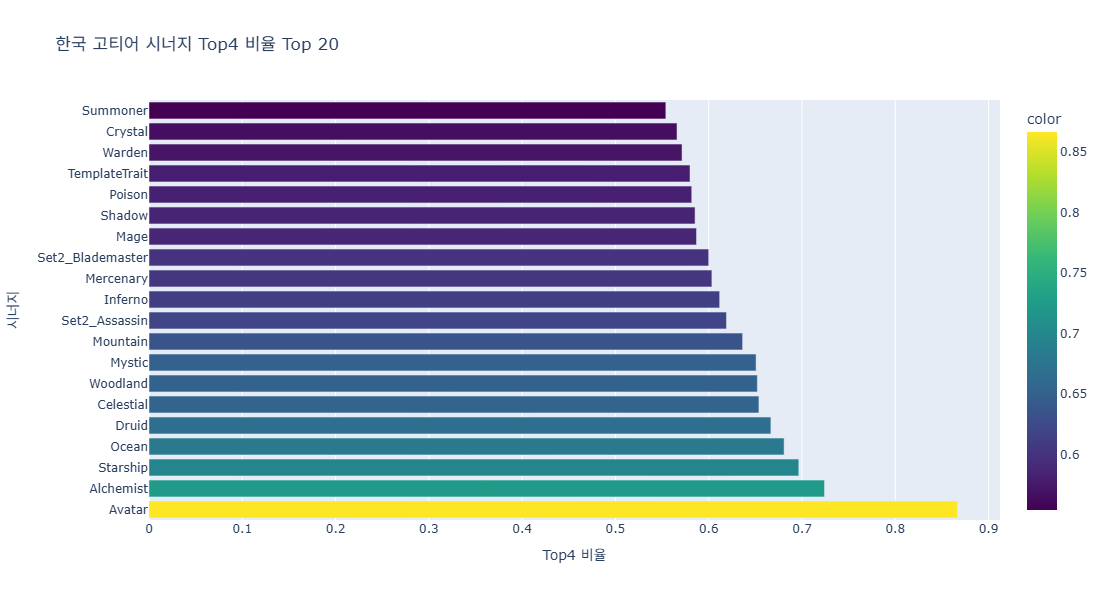

In [159]:
# 시각화 1: 시너지 Top4 비율
trait_winrate = df_trait[df_trait['is_top4']].groupby('trait').size() / df_trait.groupby('trait').size()
trait_winrate = trait_winrate.sort_values(ascending=False).head(20)

fig1 = px.bar(y=trait_winrate.index, x=trait_winrate.values, orientation='h',
              title="한국 고티어 시너지 Top4 비율 Top 20",
              labels={'x': 'Top4 비율', 'y': '시너지'},
              color=trait_winrate.values, color_continuous_scale='Viridis')
fig1.update_layout(height=600)
fig1.show()

In [160]:
# 이거 딱 1번만 실행 → plotly 완전히 정상화!
!pip install plotly==5.18.0 -q --force-reinstall

# 강제 리로드
import importlib, sys
import plotly
importlib.reload(plotly)
importlib.reload(plotly.express)

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.45.1 requires packaging<25,>=20, but you have packaging 25.0 which is incompatible.


<module 'plotly.express' from 'C:\\Users\\ckcma\\anaconda3\\Lib\\site-packages\\plotly\\express\\__init__.py'>

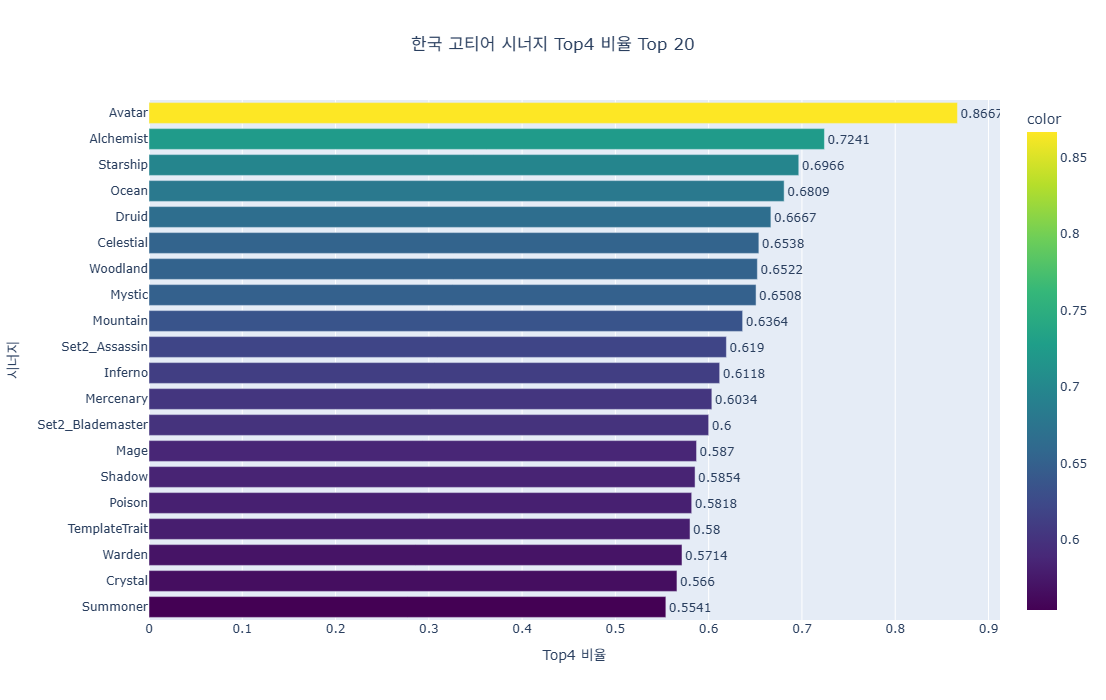

In [139]:
# 1. 필수 라이브러리 (한 번만 실행)
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

# 시각화 1: 한국 고티어 시너지 Top4 비율 Top 20
trait_winrate = df_trait[df_trait['is_top4']].groupby('trait').size() / df_trait.groupby('trait').size()
trait_winrate = trait_winrate.sort_values(ascending=False).head(20).round(4)

fig1 = px.bar(
    y=trait_winrate.index,
    x=trait_winrate.values,
    orientation='h',
    title="한국 고티어 시너지 Top4 비율 Top 20",
    labels={'x': 'Top4 비율', 'y': '시너지'},
    color=trait_winrate.values,
    color_continuous_scale='Viridis',
    text=trait_winrate.values
)
fig1.update_traces(textposition='outside')
fig1.update_layout(
    height=700,
    width=1000,
    yaxis={'categoryorder':'total ascending'},
    title_x=0.5,
    showlegend=False
)
fig1.show()

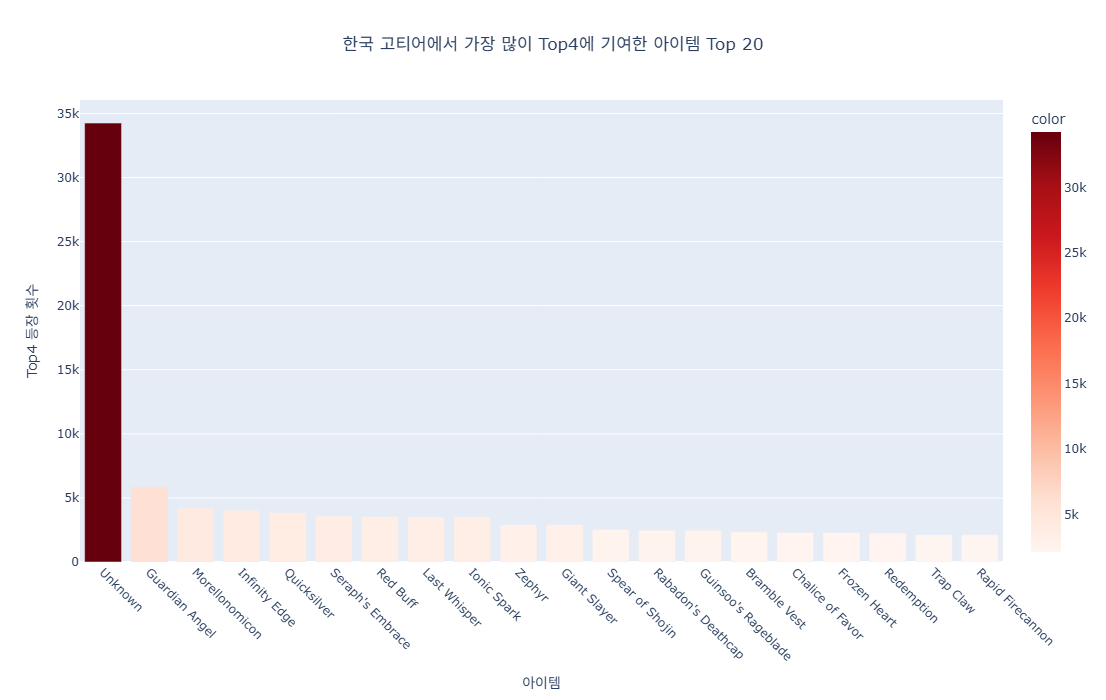

In [140]:
# 시각화 2: 아이템 Top20
top_items = df_champ[df_champ['is_top4']].explode('items').copy()
top_items['name'] = top_items['items'].map(item_name).fillna('Unknown')
item_top = top_items['name'].value_counts().head(20)

fig2 = px.bar(x=item_top.index, y=item_top.values,
              title="한국 고티어에서 가장 많이 Top4에 기여한 아이템 Top 20",
              labels={'x': '아이템', 'y': 'Top4 등장 횟수'},
              color=item_top.values, color_continuous_scale='Reds')
fig2.update_layout(height=700, width=1100, xaxis_tickangle=45, title_x=0.5)
fig2.show()

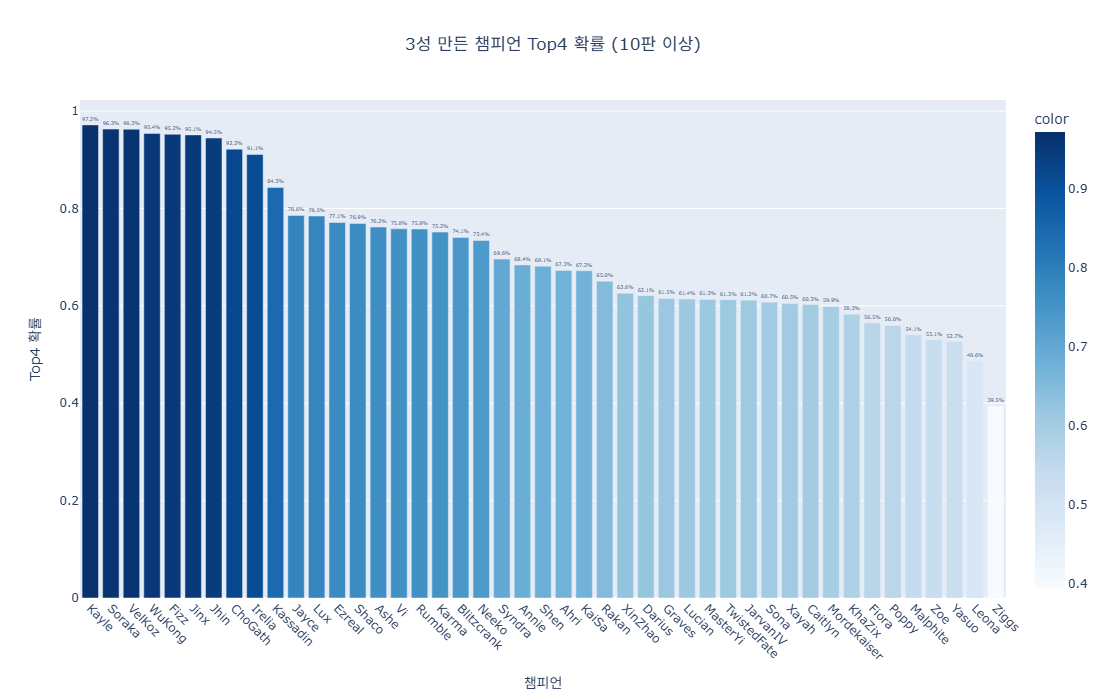

In [141]:
# 시각화 3: 3성 챔피언 승률
three = df_champ[df_champ['star'] == 3]
counts = three.groupby('champion').size()
top4s = three[three['is_top4']].groupby('champion').size()
rate = (top4s / counts).dropna()
rate = rate[counts >= 10].sort_values(ascending=False)

fig3 = px.bar(x=rate.index, y=rate.values,
              title="3성 만든 챔피언 Top4 확률 (10판 이상)",
              labels={'x': '챔피언', 'y': 'Top4 확률'},
              color=rate.values, color_continuous_scale='Blues')
fig3.update_traces(texttemplate='%{y:.1%}', textposition='outside')
fig3.update_layout(height=700, width=1100, xaxis_tickangle=45, title_x=0.5)
fig3.show()

In [142]:
# Unknown 원인 규명 코드 (이거 실행하면 정확한 원인 파악됩니다!)
print("=== Unknown 아이템 원인 진단 ===")

# 1. df_champ['items'] 샘플 확인 (tuple인지 확인)
print("\ndf_champ['items'] 샘플 (처음 5개):")
print(df_champ['items'].head())

print("\ndf_champ['items'] dtype:")
print(df_champ['items'].dtype)

# 2. 모든 아이템 ID 수집 (중복 제거)
all_items = []
for t in df_champ['items']:
    all_items.extend(t)
unique_items = sorted(set(all_items))
print(f"\n전체 고유 아이템 ID 수: {len(unique_items)}개")
print("처음 30개 ID:", unique_items[:30])

# 3. item_name 딕셔너리 키 확인
print(f"\nitem_name 딕셔너리 크기: {len(item_name)}개")
known_ids = sorted(item_name.keys())
print("item_name에 있는 ID 샘플:", known_ids[:30])

# 4. 매칭 안 되는 ID 찾기 (Unknown 원인!)
missing_ids = set(unique_items) - set(item_name.keys())
print(f"\n❌ Unknown 원인: 매칭 안 되는 ID {len(missing_ids)}개")
print("매칭 안 되는 ID 목록 (정렬):")
print(sorted(missing_ids))

# 5. Top4 데이터에서 Unknown 비율 정확히 계산
top4_items = df_champ[df_champ['is_top4']].explode('items').copy()
top4_items['mapped_name'] = top4_items['items'].map(item_name).fillna('Unknown')
unknown_rate = (top4_items['mapped_name'] == 'Unknown').mean()
print(f"\nTop4 아이템 중 Unknown 비율: {unknown_rate:.1%} ({(top4_items['mapped_name'] == 'Unknown').sum():,}개 / {len(top4_items):,}개)")

# 6. Unknown인 Top10 ID 확인 (가장 많은 Unknown ID들)
unknown_top = top4_items[top4_items['mapped_name'] == 'Unknown']['items'].value_counts().head(10)
print("\nUnknown이 가장 많은 ID Top 10:")
print(unknown_top)

# 7. CSV 파일에 없는 ID 추가 제안
print("\n💡 해결책:")
print("1. TFT_Item_CurrentVersion.csv에 위 missing_ids 추가하세요.")
print("2. 또는 아래 코드로 임시 매핑 딕셔너리 확장:")
temp_mapping = {27: "B.F. Sword", 36: "Chain Vest", 37: "Negatron Cloak", 47: "Giant's Belt", 57: "Sparring Gloves"}  # 예시
print("임시 추가 예시:", temp_mapping)

=== Unknown 아이템 원인 진단 ===

df_champ['items'] 샘플 (처음 5개):
0              ()
1           (11,)
2              ()
3    (14, 34, 34)
4              ()
Name: items, dtype: object

df_champ['items'] dtype:
object

전체 고유 아이템 ID 수: 59개
처음 30개 ID: [1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 16, 17, 18, 19, 22, 23, 24, 25, 26, 27, 28, 29, 33, 34, 35, 36]

item_name 딕셔너리 크기: 54개
item_name에 있는 ID 샘플: [1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 16, 17, 18, 19, 22, 23, 24, 25, 26, 27, 28, 29, 33, 34, 35, 36]

❌ Unknown 원인: 매칭 안 되는 ID 5개
매칭 안 되는 ID 목록 (정렬):
[10005, 10201, 10202, 10203, 10204]

Top4 아이템 중 Unknown 비율: 25.8% (34,248개 / 132,752개)

Unknown이 가장 많은 ID Top 10:
items
10204    47
10202    39
10201    31
10203    28
10005     4
Name: count, dtype: int64

💡 해결책:
1. TFT_Item_CurrentVersion.csv에 위 missing_ids 추가하세요.
2. 또는 아래 코드로 임시 매핑 딕셔너리 확장:
임시 추가 예시: {27: 'B.F. Sword', 36: 'Chain Vest', 37: 'Negatron Cloak', 47: "Giant's Belt", 57: 'Sparring Gloves'}
